In [7]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Load dataset into a pandas DataFrame and check the first few rows
data = pd.read_csv("data.csv")
display(data.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [9]:
# Create Workout_Intensity feature as ratio of Avg_BPM to Resting_BPM
data["Workout_Intensity"] = data["Avg_BPM"] / data["Resting_BPM"]

# Handle infinite values (e.g., if Resting_BPM = 0) and drop missing data
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Check the updated dataset
display(data.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Workout_Intensity
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,2.616667
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,2.287879
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,2.259259
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,2.928571
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,2.323529


In [10]:
# Define target variable and selected features
target = "Calories_Burned"
features = [
    "Age","Gender","Weight (kg)","Height (m)","Max_BPM","Avg_BPM",
    "Resting_BPM","Session_Duration (hours)","Workout_Type",
    "Fat_Percentage","Water_Intake (liters)","Workout_Frequency (days/week)",
    "Experience_Level","BMI","Workout_Intensity"
]

X = data[features]  # Features for the model
y = data[target]    # Target variable

In [11]:
# Split data into training and testing sets (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Identify categorical and numeric columns
categorical_cols = ["Gender", "Workout_Type"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing pipeline:
# - Standardize numeric features
# - One-hot encode categorical features (drop first category to avoid dummy trap)
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
])

We will train three regression models:  
1. **Linear Regression** – baseline model, simple linear relationships.  
2. **Polynomial Regression Degree 2** – captures quadratic effects in the data.  
3. **Polynomial Regression Degree 3** – captures more complex, cubic interactions.  

Using a pipeline ensures preprocessing steps are applied automatically.

In [13]:
# Define linear and polynomial regression pipelines
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

poly2_model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

poly3_model = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("regressor", LinearRegression())
])

# Store models in a dictionary for easy iteration
models = {
    "Linear Regression": linear_model,
    "Polynomial Degree 2": poly2_model,
    "Polynomial Degree 3": poly3_model
}


In [14]:
# Train each model on the training set
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

Linear Regression trained successfully
Polynomial Degree 2 trained successfully
Polynomial Degree 3 trained successfully


In [ ]:
# Evaluaate each model and save the performace
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)  # Model error
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)           # Variance explained
    results[name] = {"MSE": mse, "RMSE": rmse, "R2": r2, "y_pred": y_pred}
    print(f"{name}: MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")


Linear Regression: MSE=1662.19, R2=0.9801
Polynomial Degree 2: MSE=678.66, R2=0.9919
Polynomial Degree 3: MSE=19471.36, R2=0.7666


## Correlation Heatmap
Visualizing correlations between numeric features can reveal relationships and potential multicollinearity.  
This helps interpret which features might be strongly related to calories burned.

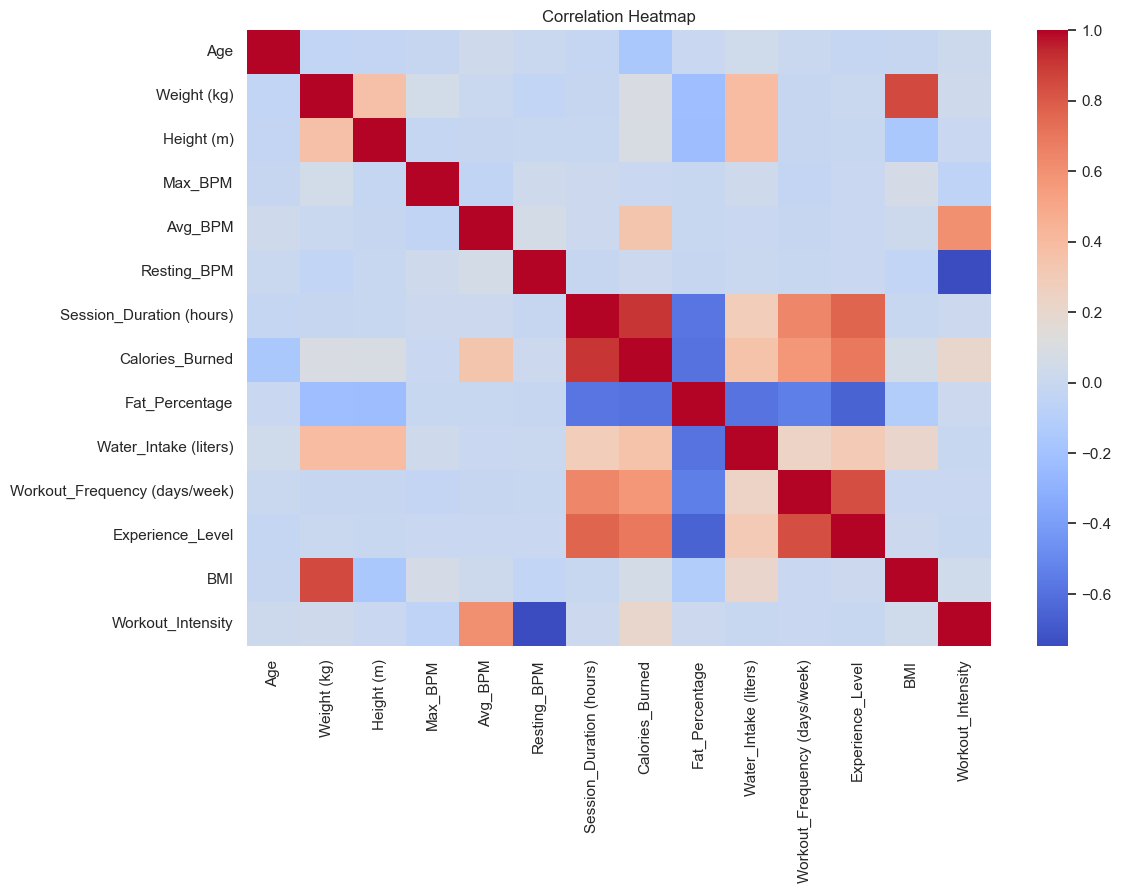

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


## Pairplot / Scatter Matrix
A pairplot allows visual inspection of feature interactions and distributions.  
We sample a subset to keep it readable. The diagonal shows the kernel density estimate of each variable.

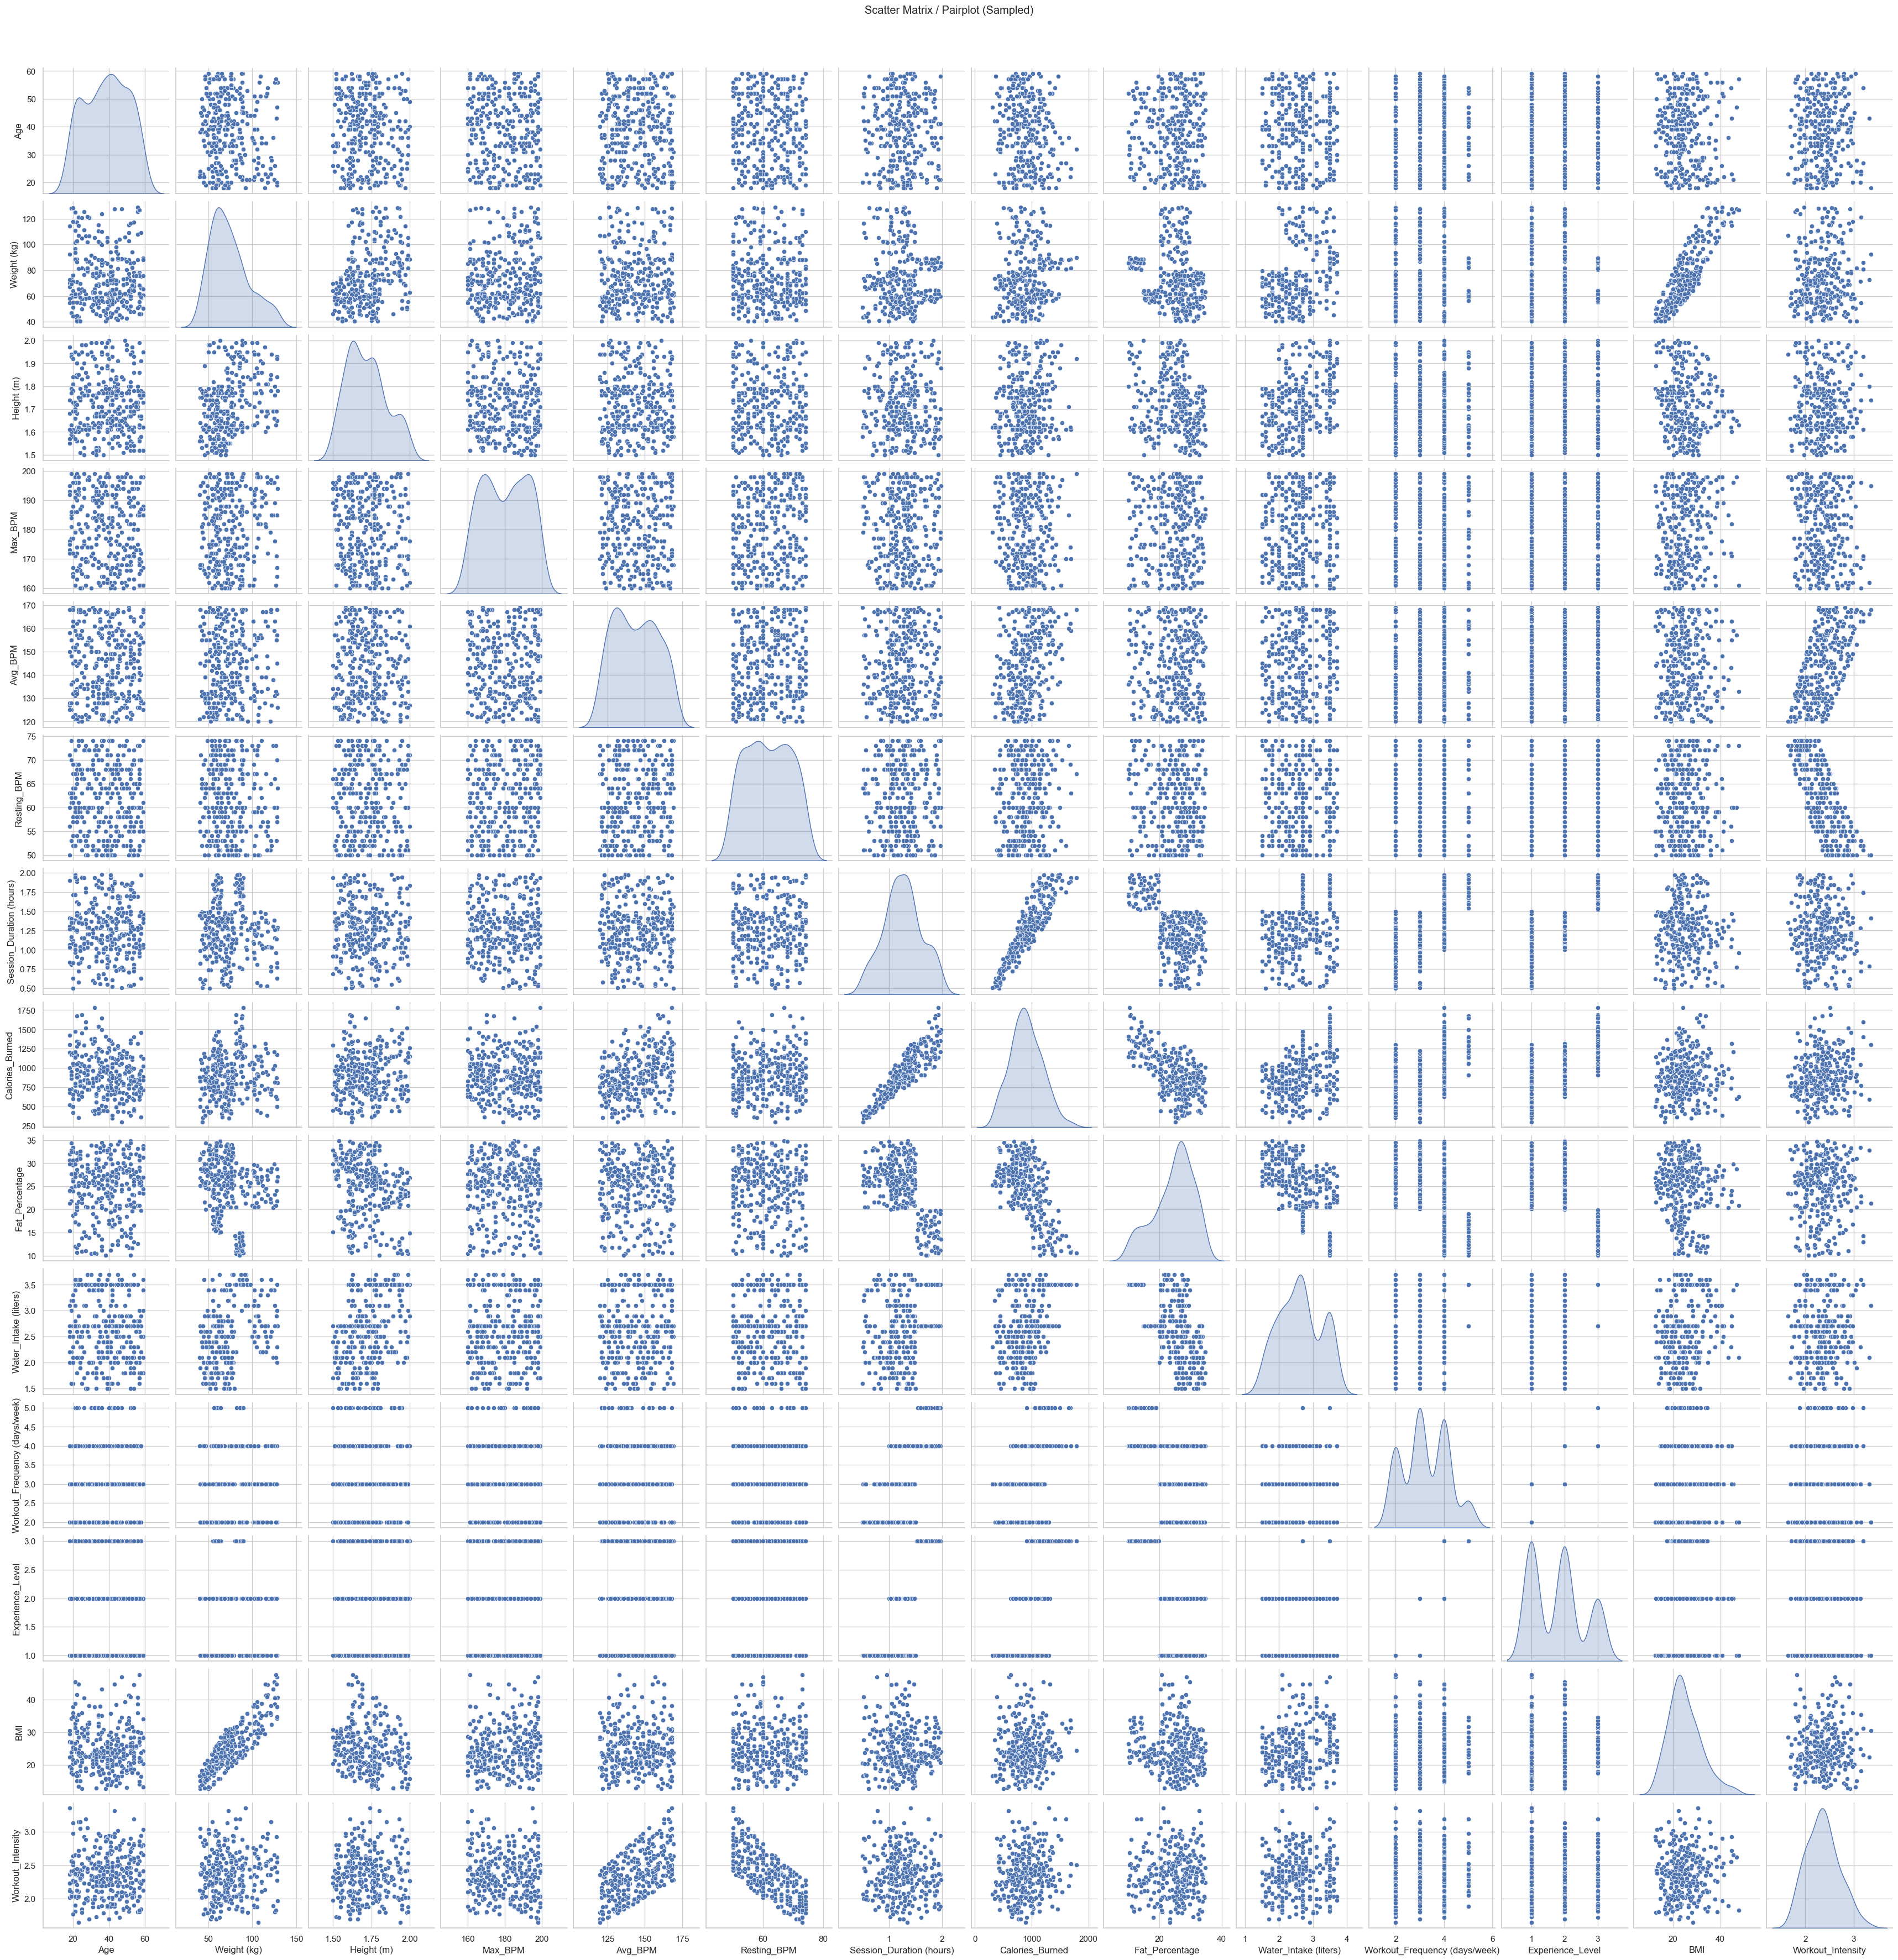

In [17]:
sns.pairplot(data.sample(min(300, len(data))), diag_kind="kde")
plt.suptitle("Scatter Matrix / Pairplot (Sampled)", y=1.02)
plt.show()

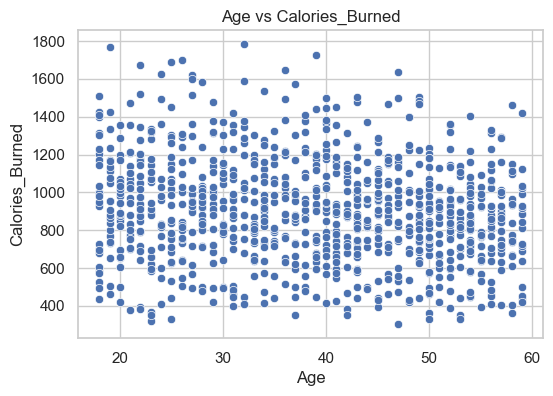

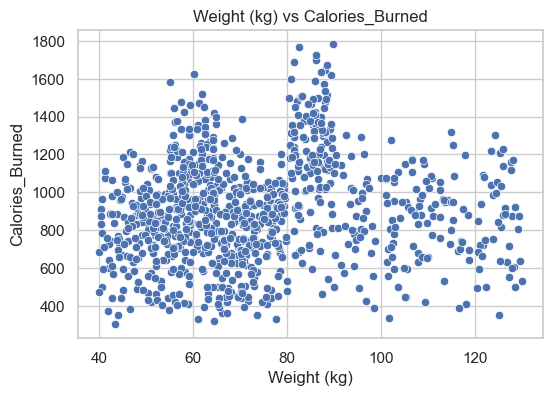

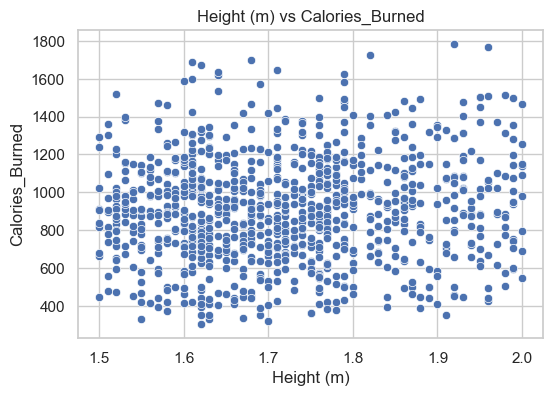

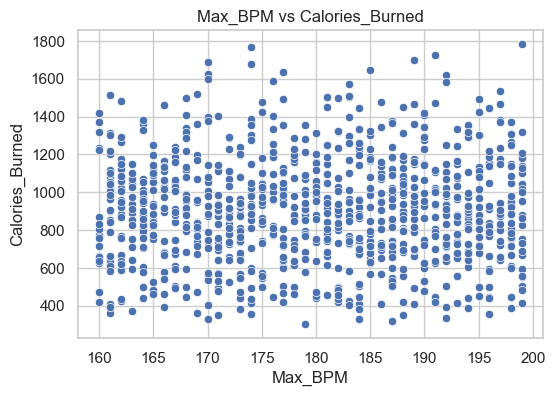

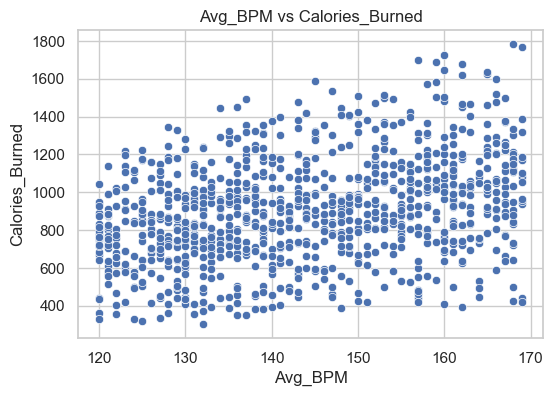

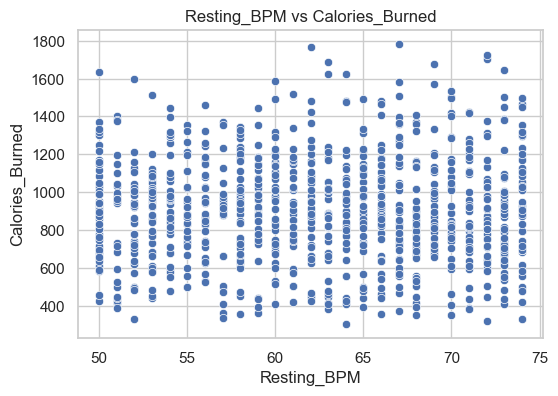

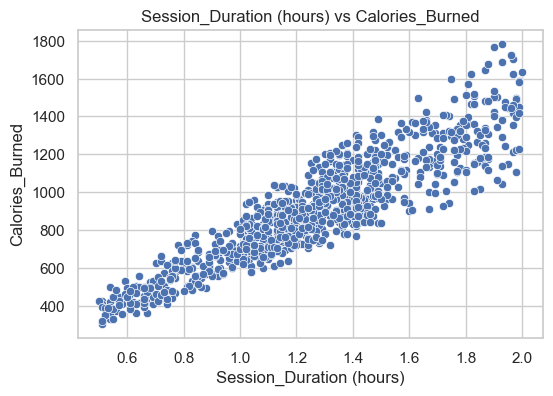

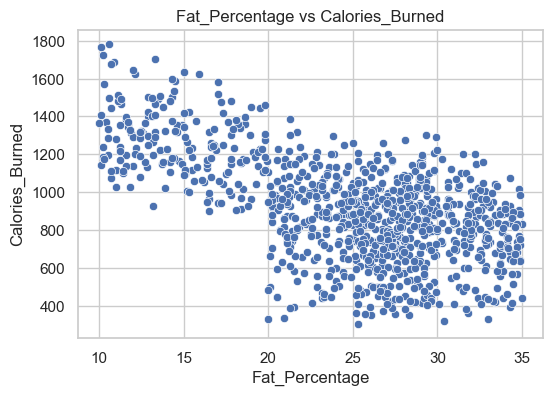

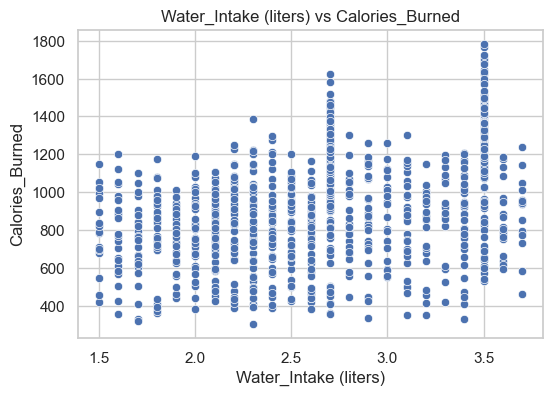

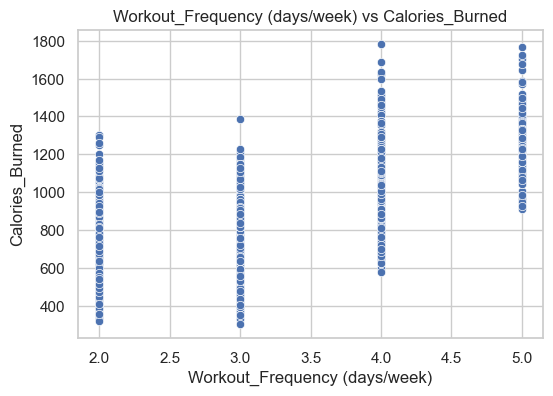

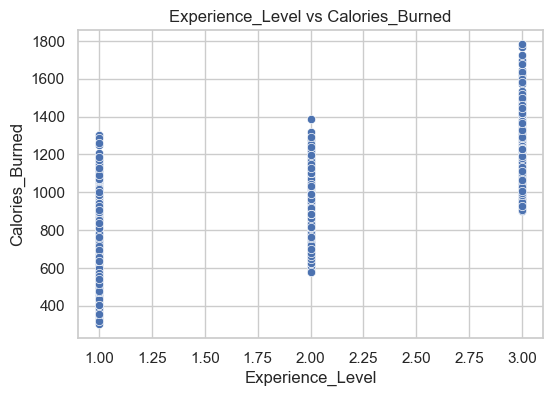

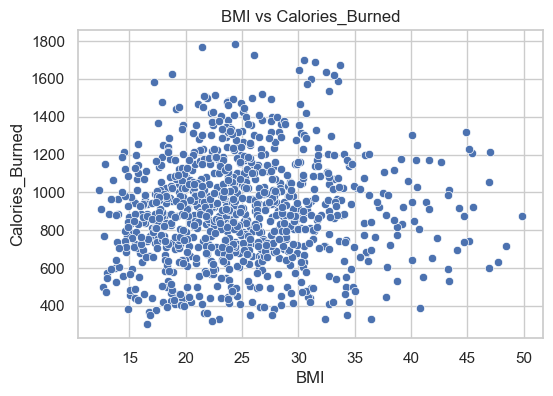

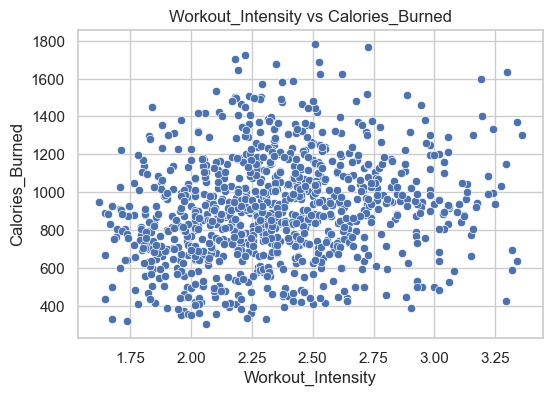

In [18]:
# Visualize each numeric feature against Calories_Burned
numeric_features = data.select_dtypes(include=np.number).columns.drop("Calories_Burned")

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data[col].to_numpy(), y=data["Calories_Burned"].to_numpy())
    plt.title(f"{col} vs Calories_Burned")  # Identify potential trends
    plt.xlabel(col)
    plt.ylabel("Calories_Burned")
    plt.show()

## Predicted vs Actual Scatter Plots
These plots help evaluate how close model predictions are to actual values.  
A perfect model would have all points lying on the diagonal line.

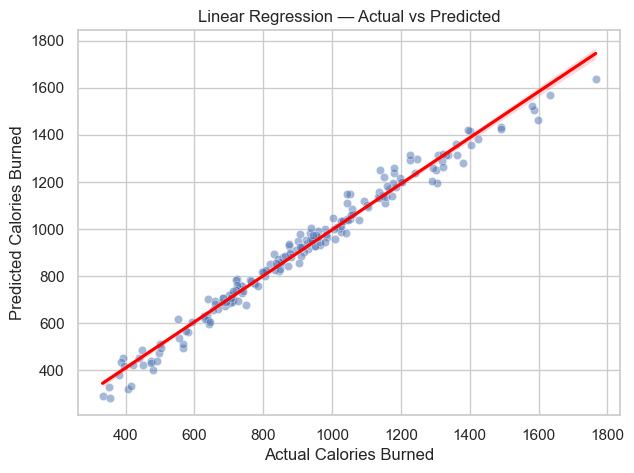

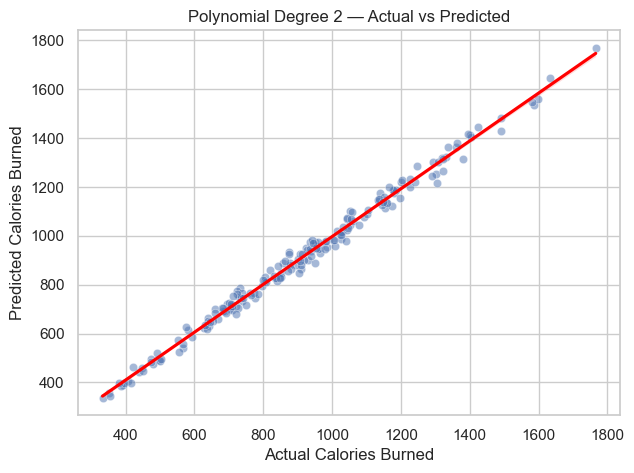

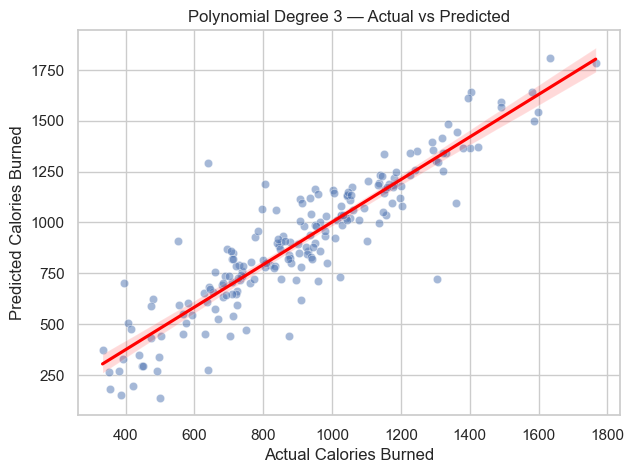

In [19]:
for name, res in results.items():
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=y_test.to_numpy(), y=res["y_pred"], alpha=0.5)
    sns.regplot(x=y_test.to_numpy(), y=res["y_pred"], scatter=False, line_kws={"color":"red"})
    plt.xlabel("Actual Calories Burned")
    plt.ylabel("Predicted Calories Burned")
    plt.title(f"{name} — Actual vs Predicted")
    plt.show()


## Residual plots
Residuals = difference between actual and predicted values, this plot will help inspect residuals for patterns suggesting non-linear relationships or heteroscedasticity


In [ ]:
# Dispaly residual plots with KDE for each model
for name, res in results.items():
    residuals = y_test.to_numpy() - res["y_pred"]
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=res["y_pred"], y=residuals, alpha=0.5)
    sns.kdeplot(residuals, color="red", lw=2)  # Residual distribution
    plt.axhline(0, linestyle="--", color="black")
    plt.xlabel("Predicted Calories")
    plt.ylabel("Residuals")
    plt.title(f"{name} — Residual Plot with KDE")
    plt.show()


## Linear Regression Feature Coefficients
Inspecting coefficients shows how each feature contributes to the prediction.  
Positive coefficients increase predicted calories, negative coefficients decrease them.

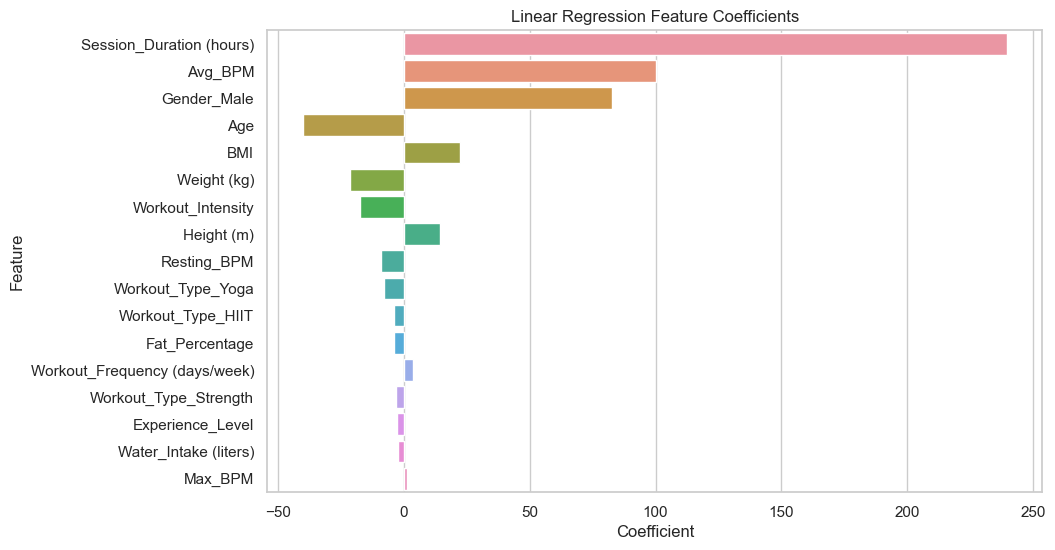

In [20]:
linear_pipeline = models["Linear Regression"]
numeric_features_scaled = numeric_cols
categorical_features_encoded = linear_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out()
all_features = list(itertools.chain(numeric_features_scaled, categorical_features_encoded))

coefficients = linear_pipeline.named_steps['regressor'].coef_
coef_df = pd.DataFrame({"Feature": all_features, "Coefficient": coefficients})
coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Linear Regression Feature Coefficients")
plt.show()

## Heatmap

Taught very clearly in class and assignments, one of the most basic graphs one can make, so I won't discribe it here

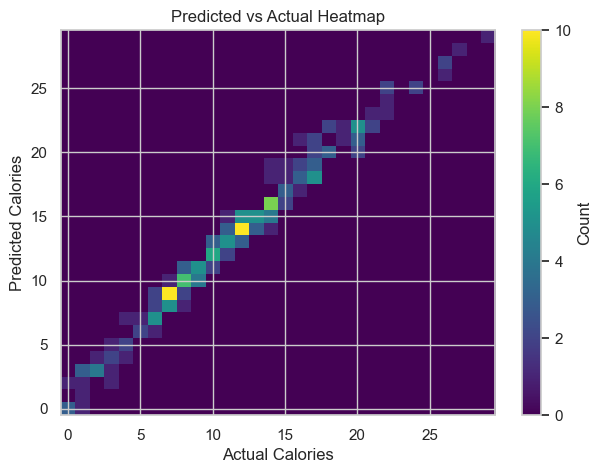

In [21]:
y_pred = results["Linear Regression"]["y_pred"]
heatmap_data, xedges, yedges = np.histogram2d(y_test.to_numpy(), y_pred, bins=30)

plt.figure(figsize=(7,5))
plt.imshow(heatmap_data.T, origin='lower', cmap="viridis", aspect="auto")
plt.colorbar(label="Count")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Predicted vs Actual Heatmap")
plt.show()
